# Exploratory Data Analysis

In [1]:
import importlib

import matplotlib.pyplot as plt
import pandas as pd

import attrition_analysis.associations_test as associations_test
import attrition_analysis.data_selection as data_selection
import attrition_analysis.logistic_models_utils as logistic_models_utils
import attrition_analysis.multicollinearity as multicollinearity
import attrition_analysis.statistics_utils as statistics_utils

importlib.reload(data_selection)
importlib.reload(statistics_utils)
importlib.reload(associations_test)
importlib.reload(multicollinearity)
importlib.reload(logistic_models_utils)

from attrition_analysis.associations_test import (
    categorical_predictors_cramer_table,
    check_chi_square_assumptions,
    chi_square_table,
    cramer_table,
)
from attrition_analysis.data_selection import CATEGORICAL_MODEL_VARS, get_categorical_vars
from attrition_analysis.logistic_models_utils import (
    compare_logistic_models,
    run_logistic_models,
)
from attrition_analysis.multicollinearity import vif_categorical_table
from attrition_analysis.statistics_utils import attrition_summary

df = pd.read_csv("../../data/clean/Employee-Attrition_Clean.csv")

target = "AttritionFlag"

df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,EducationField,EmployeeCount,EmployeeNumber,Gender,...,IncomeGroup,EducationLevel,StockOption,JobLevelGroup,SatisfactionLevel,PerformanceRatingLevel,EnvironmentSatisfactionLevel,JobInvolvementLevel,RelationshipSatisfactionLevel,WorkLifeBalanceLevel
0,41,Yes,Travel_Rarely,1102,Sales,1,Life Sciences,1,1,Female,...,Medium,College,No Options,Junior Level,Very High,Excellent,Medium,High,Low,Bad
1,49,No,Travel_Frequently,279,Research & Development,8,Life Sciences,1,2,Male,...,Medium,Below College,Low,Junior Level,Medium,Outstanding,High,Medium,Very High,Better
2,37,Yes,Travel_Rarely,1373,Research & Development,2,Other,1,4,Male,...,Low,College,No Options,Entry Level,High,Excellent,Very High,Medium,Medium,Better
3,33,No,Travel_Frequently,1392,Research & Development,3,Life Sciences,1,5,Female,...,Low,Master,No Options,Entry Level,High,Excellent,Very High,High,High,Better
4,27,No,Travel_Rarely,591,Research & Development,2,Medical,1,7,Male,...,Medium,Below College,Low,Entry Level,Medium,Excellent,Low,High,Very High,Better
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,Medical,1,2061,Male,...,Low,College,Low,Junior Level,Very High,Excellent,High,Very High,High,Better
1466,39,No,Travel_Rarely,613,Research & Development,6,Medical,1,2062,Male,...,High,Below College,Low,Mid Level,Low,Excellent,Very High,Medium,Low,Better
1467,27,No,Travel_Rarely,155,Research & Development,4,Life Sciences,1,2064,Male,...,High,Bachelor,Low,Junior Level,Medium,Outstanding,Medium,Very High,Medium,Better
1468,49,No,Travel_Frequently,1023,Sales,2,Medical,1,2065,Male,...,Medium,Bachelor,No Options,Junior Level,Medium,Excellent,Very High,Medium,Very High,Good


# Attrition By - Stats

In [2]:
categorical_vars = get_categorical_vars(df)

for col in categorical_vars:
    print(f'\n{col}')
    display(attrition_summary(df, col))


BusinessTravel


,BusinessTravel,total_employees,attrition_count,attrition_rate
0,Travel_Frequently,277,69,24.91
1,Travel_Rarely,1043,156,14.96
2,Non-Travel,150,12,8.00



Department


,Department,total_employees,attrition_count,attrition_rate
0,Sales,446,92,20.63
1,Human Resources,63,12,19.05
2,Research & Development,961,133,13.84



EducationField


...

,JobInvolvementLevel,total_employees,attrition_count,attrition_rate
0,Low,83,28,33.73
1,Medium,375,71,18.93
2,High,868,125,14.40
3,Very High,144,13,9.03



RelationshipSatisfactionLevel


,RelationshipSatisfactionLevel,total_employees,attrition_count,attrition_rate
0,Low,276,57,20.65
1,High,459,71,15.47
2,Medium,303,45,14.85
3,Very High,432,64,14.81



WorkLifeBalanceLevel


,WorkLifeBalanceLevel,total_employees,attrition_count,attrition_rate
0,Bad,80,25,31.25
1,Best,153,27,17.65
2,Good,344,58,16.86
3,Better,893,127,14.22


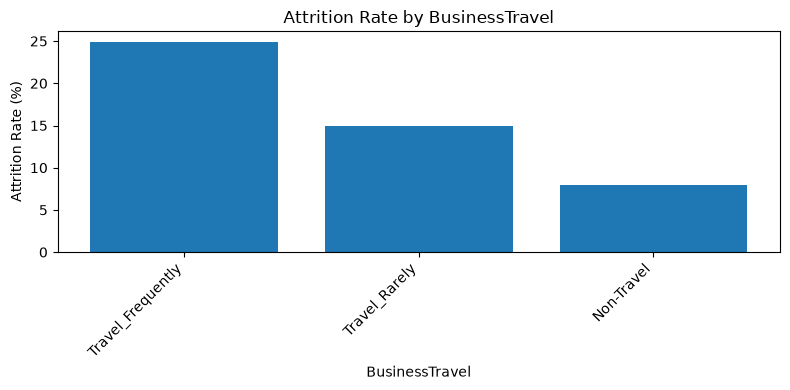

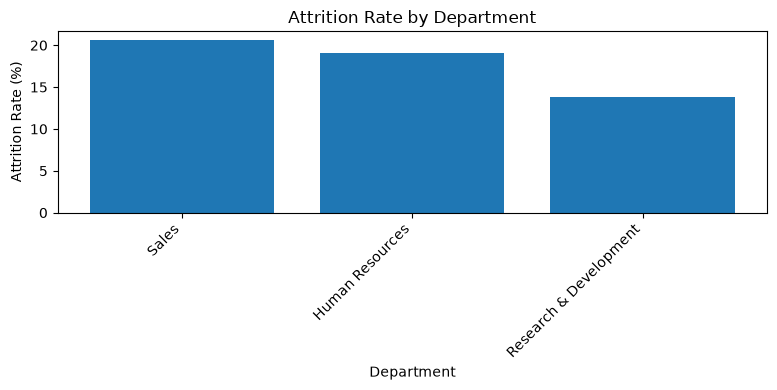

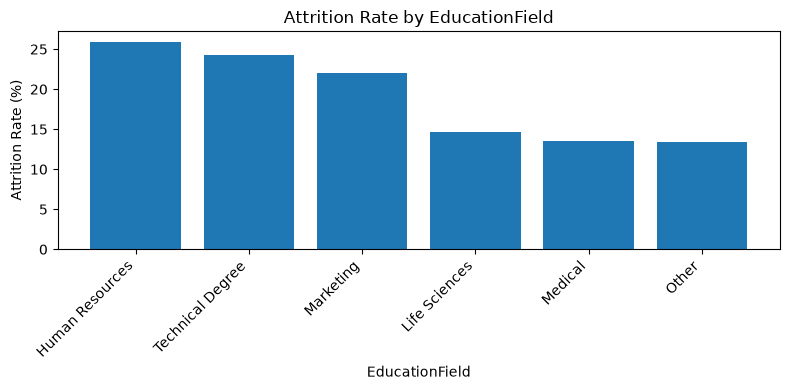

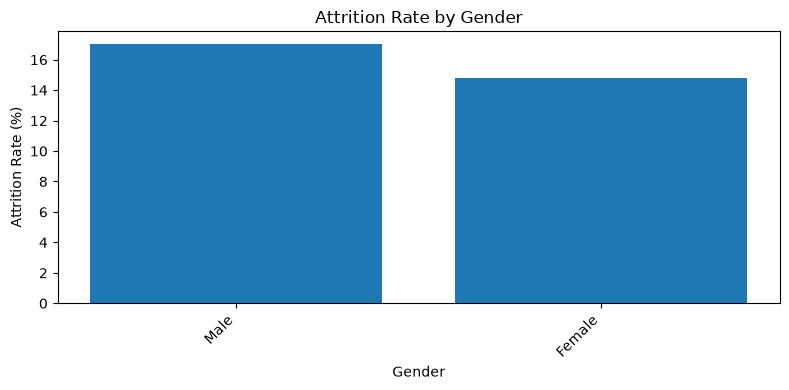

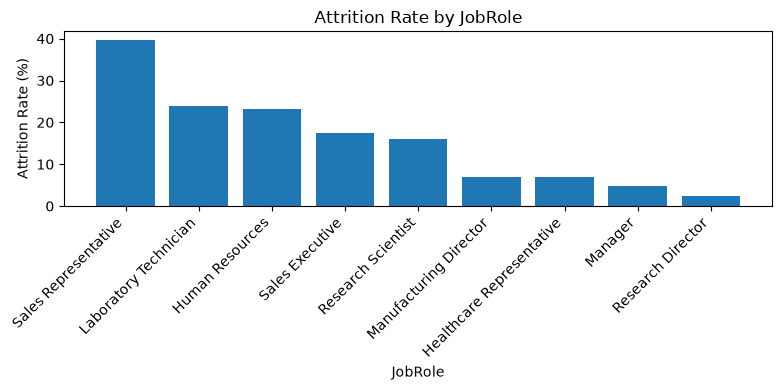

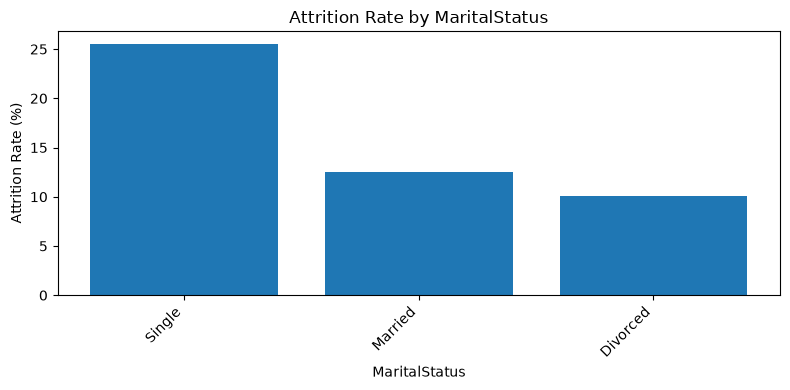

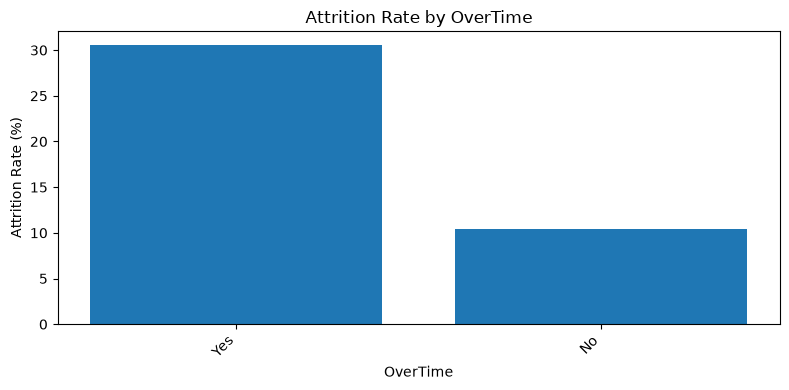

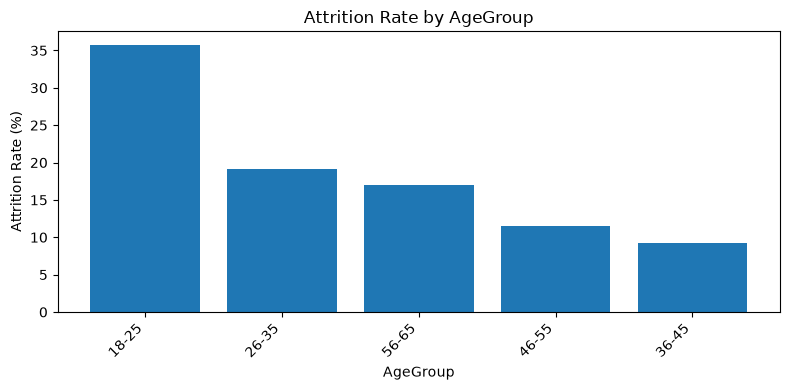

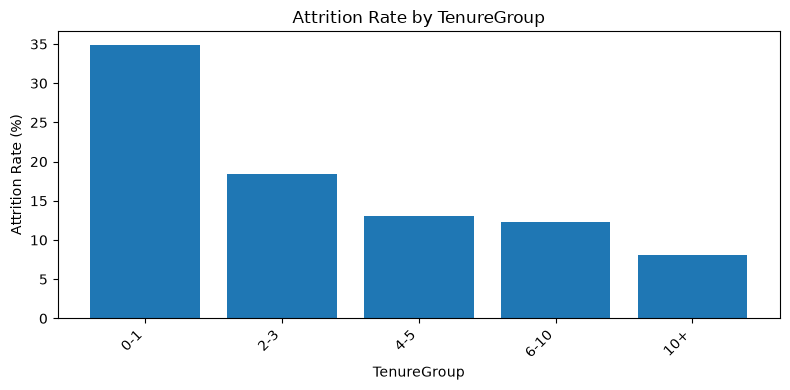

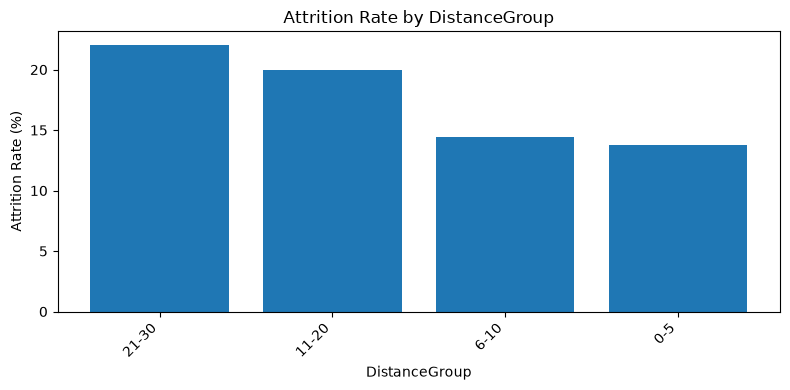

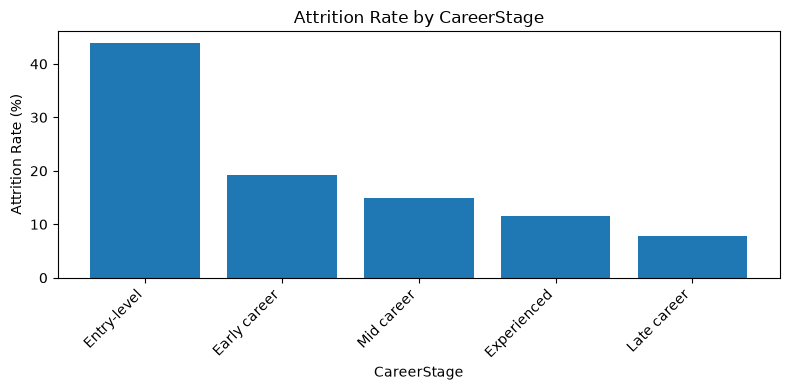

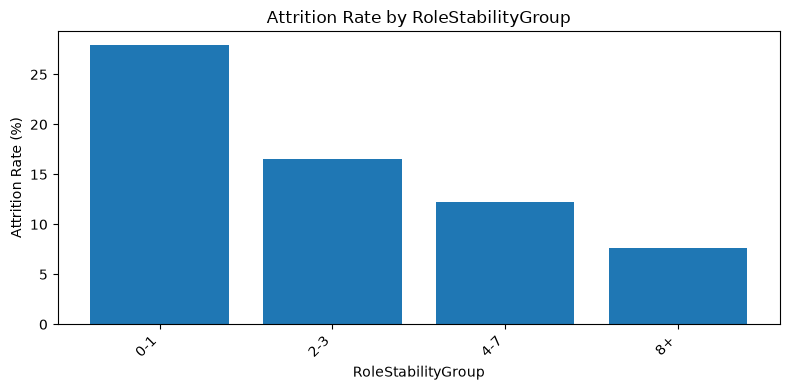

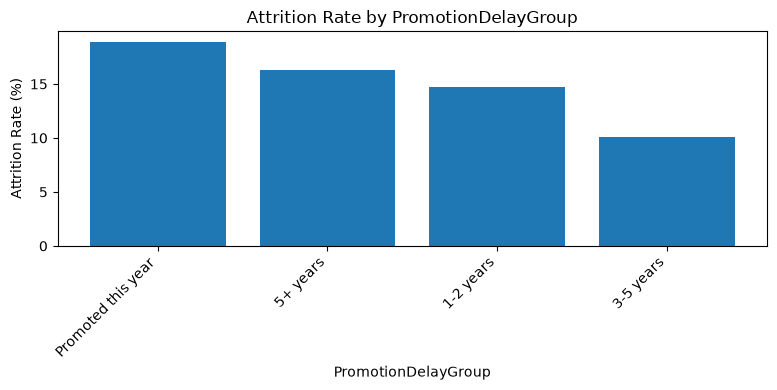

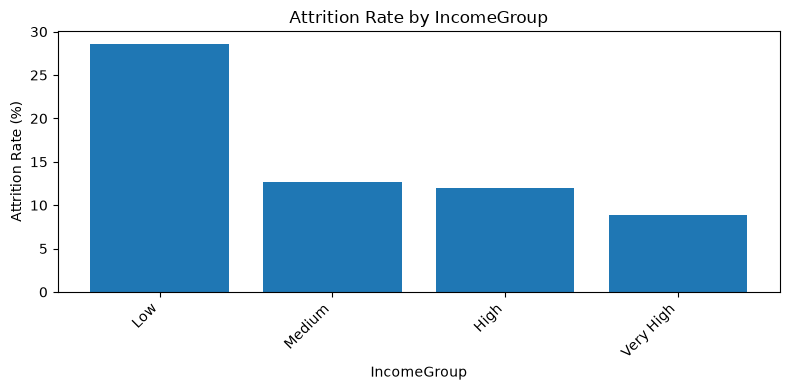

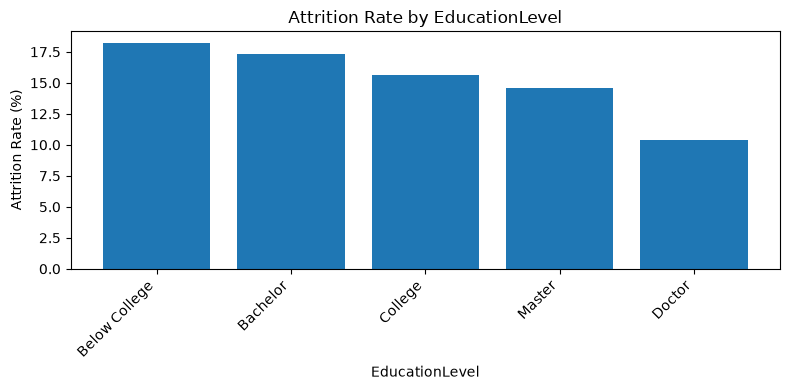

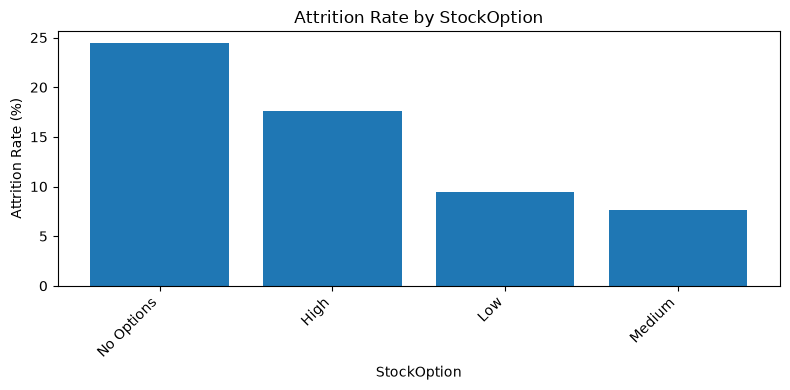

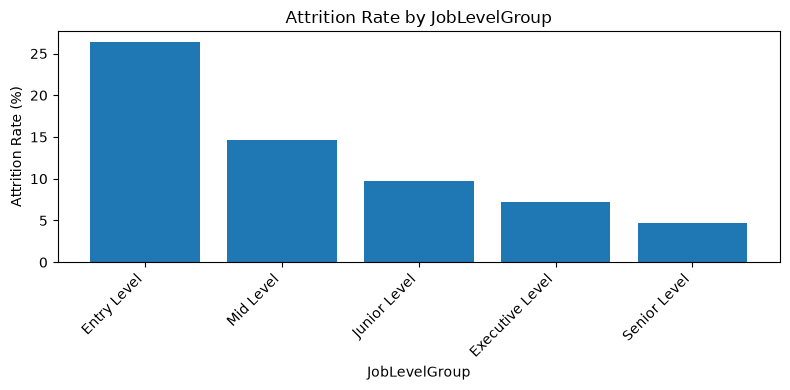

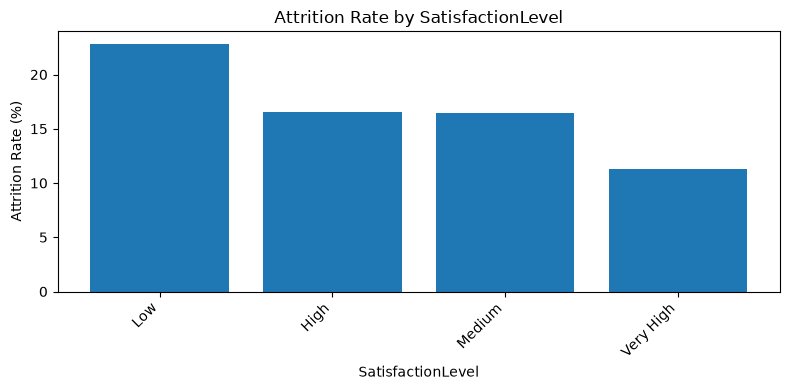

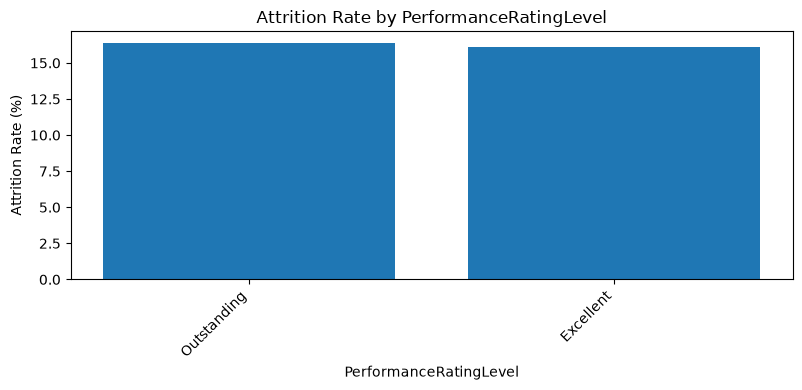

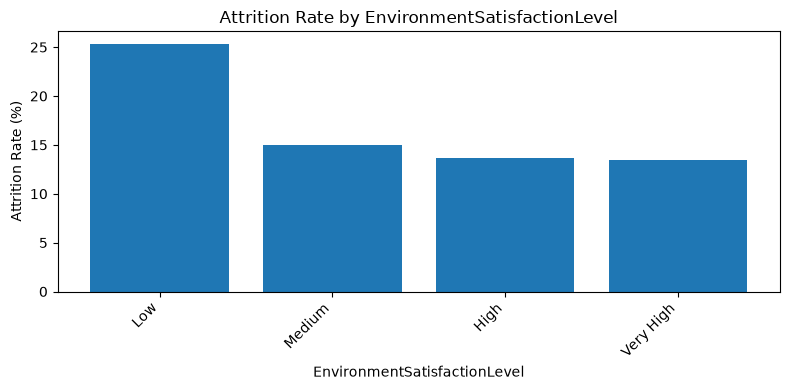

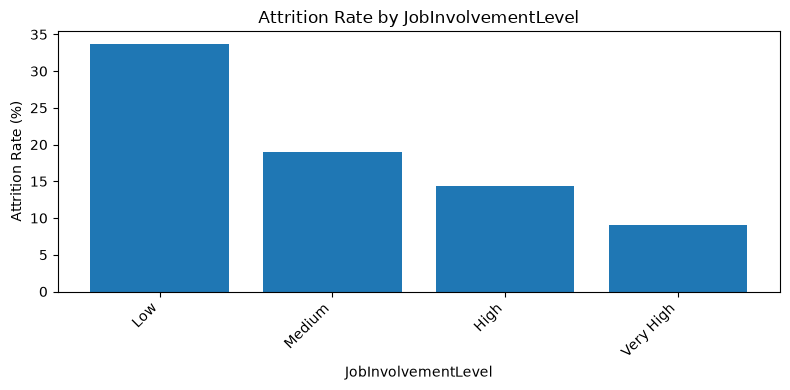

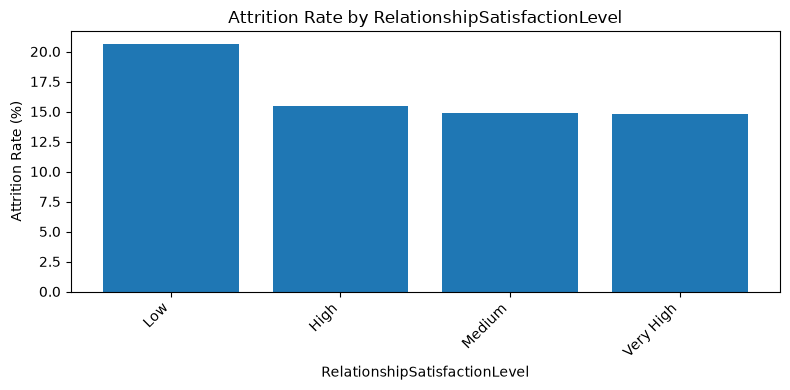

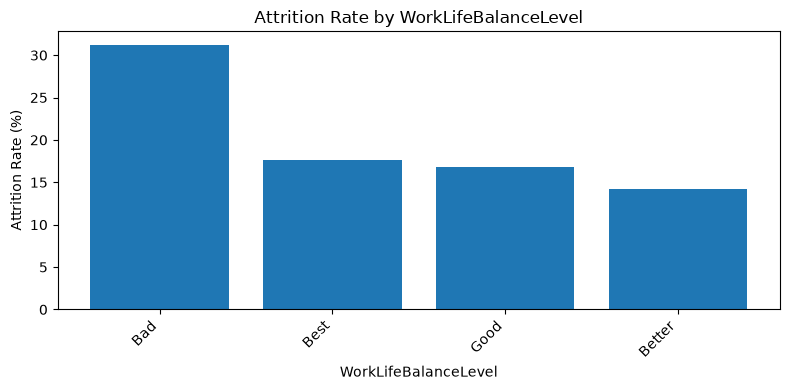

In [3]:
for col in categorical_vars:
    if col != "Attrition":
        summary = attrition_summary(df, col)

        plt.figure(figsize=(8, 4))
        plt.bar(summary[col], summary["attrition_rate"])

        plt.title(f"Attrition Rate by {col}")
        plt.xlabel(col)
        plt.ylabel("Attrition Rate (%)")

        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()


# Análises de Correlações e de Colinearidade

In [4]:
print(f'Verificar Pressupostos para o teste do Qui-Quadradro')
display(check_chi_square_assumptions(df, "Attrition"))

print(f'\nTabela do Qui-Quadrado')
display(chi_square_table(df, "Attrition"))
    
print(f'\nTabela de Cramer')
display(cramer_table(df, "Attrition"))

Verificar Pressupostos para o teste do Qui-Quadradro


,Primary_Variable,Secondary_Variable,Rows,Columns,Total_Cells,Cells_Expected_Below_5,Percent_Expected_Below_5,Min_Expected,Assumptions_OK
0,Attrition,EducationField,2,6,12,1,8.33,4.35,Sim
1,Attrition,BusinessTravel,2,3,6,0,0.00,24.18,Sim
2,Attrition,Department,2,3,6,0,0.00,10.16,Sim
3,Attrition,Gender,2,2,4,0,0.00,94.80,Sim
4,Attrition,JobRole,2,9,18,0,0.00,8.38,Sim
5,Attrition,MaritalStatus,2,3,6,0,0.00,52.72,Sim
6,Attrition,OverTime,2,2,4,0,0.00,67.07,Sim
7,Attrition,AgeGroup,2,5,10,0,0.00,7.58,Sim
8,Attrition,TenureGroup,2,5,10,0,0.00,34.66,Sim
9,Attrition,DistanceGroup,2,4,8,0,0.00,32.89,Sim



Tabela do Qui-Quadrado


,Primary_Variable,Secondary_Variable,Chi_square,p_value,Significativo
0,Attrition,CareerStage,88.316,0.0000,Sim
1,Attrition,OverTime,87.564,0.0000,Sim
2,Attrition,JobRole,86.190,0.0000,Sim
3,Attrition,TenureGroup,75.592,0.0000,Sim
4,Attrition,JobLevelGroup,72.529,0.0000,Sim
5,Attrition,IncomeGroup,64.287,0.0000,Sim
6,Attrition,StockOption,60.598,0.0000,Sim
7,Attrition,AgeGroup,59.439,0.0000,Sim
8,Attrition,RoleStabilityGroup,49.451,0.0000,Sim
9,Attrition,MaritalStatus,46.164,0.0000,Sim



Tabela de Cramer


,Primary_Variable,Secondary_Variable,Cramers_V,p_value,Significativo,Association
0,Attrition,CareerStage,0.245,0.0000,Sim,Moderada
1,Attrition,OverTime,0.244,0.0000,Sim,Moderada
2,Attrition,JobRole,0.242,0.0000,Sim,Moderada
3,Attrition,TenureGroup,0.227,0.0000,Sim,Moderada
4,Attrition,JobLevelGroup,0.222,0.0000,Sim,Moderada
5,Attrition,IncomeGroup,0.209,0.0000,Sim,Moderada
6,Attrition,StockOption,0.203,0.0000,Sim,Moderada
7,Attrition,AgeGroup,0.201,0.0000,Sim,Moderada
8,Attrition,RoleStabilityGroup,0.183,0.0000,Sim,Fraca
9,Attrition,MaritalStatus,0.177,0.0000,Sim,Fraca


In [5]:
predictors_cramer_table = categorical_predictors_cramer_table(df, categorical_vars)

display(predictors_cramer_table)

,Variable_1,Variable_2,Cramers_V,p_value,Significativo,Association
0,Department,JobRole,0.939,0.0000,Sim,Forte
1,TenureGroup,RoleStabilityGroup,0.700,0.0000,Sim,Forte
2,IncomeGroup,JobLevelGroup,0.688,0.0000,Sim,Forte
3,JobRole,IncomeGroup,0.607,0.0000,Sim,Forte
4,Department,EducationField,0.590,0.0000,Sim,Forte
...,...,...,...,...,...,...
248,Gender,PerformanceRatingLevel,0.012,0.6473,Não,Muito fraca
249,OverTime,JobInvolvementLevel,0.010,0.9843,Não,Muito fraca
250,Department,OverTime,0.008,0.9543,Não,Muito fraca
251,BusinessTravel,Department,0.008,0.9952,Não,Muito fraca


In [6]:
moderate_or_strong_pairs = predictors_cramer_table[predictors_cramer_table["Cramers_V"] >= 0.20]

display(moderate_or_strong_pairs)

,Variable_1,Variable_2,Cramers_V,p_value,Significativo,Association
0,Department,JobRole,0.939,0.0,Sim,Forte
1,TenureGroup,RoleStabilityGroup,0.700,0.0,Sim,Forte
2,IncomeGroup,JobLevelGroup,0.688,0.0,Sim,Forte
3,JobRole,IncomeGroup,0.607,0.0,Sim,Forte
4,Department,EducationField,0.590,0.0,Sim,Forte
5,MaritalStatus,StockOption,0.583,0.0,Sim,Forte
6,JobRole,JobLevelGroup,0.573,0.0,Sim,Forte
7,CareerStage,IncomeGroup,0.553,0.0,Sim,Forte
8,CareerStage,JobLevelGroup,0.515,0.0,Sim,Forte
9,TenureGroup,CareerStage,0.458,0.0,Sim,Forte


In [7]:
vif_cat_table = vif_categorical_table(df, categorical_vars, target="Attrition")

vif_cat_table[vif_cat_table["VIF"]>5]

,Feature,VIF,Multicollinearity
0,Department_Sales,45.197,Forte
1,Department_Research & Development,44.733,Forte
2,EducationField_Life Sciences,24.568,Forte
3,EducationField_Medical,22.099,Forte
4,JobRole_Sales Executive,14.860,Forte
5,EducationField_Marketing,11.113,Forte
6,EducationField_Technical Degree,9.055,Moderada
7,CareerStage_Late career,8.582,Moderada
8,TenureGroup_6-10,7.814,Moderada
9,JobLevelGroup_Senior Level,7.611,Moderada


# Regressão Logística

In [8]:
categorical_models, categorical_results = run_logistic_models(
    df=df,
    models_vars_dict=CATEGORICAL_MODEL_VARS,
    target="AttritionFlag",
    categorical=True,
    show_summary=False
)

In [9]:
categorical_comparison = compare_logistic_models(categorical_models)

categorical_comparison.round(4)

,Model,N_Observations,Df_Model,Log_Likelihood,LL_Null,LLR_p_value,AIC,BIC,Pseudo_R2
0,Modelo 5 — Estabilidade e Benefícios,1470,24,-491.0334,-649.2914,0.0,1032.0669,1164.3923,0.2437
1,Modelo 6 — Perfil Pessoal,1470,24,-492.1317,-649.2914,0.0,1034.2633,1166.5888,0.2420
2,Modelo 1 — Função Profissional,1470,26,-492.1872,-649.2914,0.0,1038.3744,1181.2859,0.2420
3,Modelo 4 — Trajetória Organizacional,1470,22,-496.8638,-649.2914,0.0,1039.7277,1161.4671,0.2348
4,Modelo 2 — Nível Hierárquico,1470,22,-503.0292,-649.2914,0.0,1052.0583,1173.7977,0.2253
5,Modelo 3 — Faixa Salarial,1470,21,-507.1187,-649.2914,0.0,1058.2374,1174.6838,0.2190
6,Modelo 7 — Reduzido Conservador,1470,18,-542.3755,-649.2914,0.0,1122.7510,1223.3183,0.1647


# Modelo 1 — Função Profissional

Este modelo é focado no papel profissional do funcionário, utilizando `JobRole` como variável principal do bloco. Inclui também variáveis relacionadas às condições de trabalho, satisfação, envolvimento e distância até o trabalho.

**Variáveis do modelo:** `OverTime`, `JobRole`, `BusinessTravel`, `JobInvolvementLevel`, `EnvironmentSatisfactionLevel`, `SatisfactionLevel`, `WorkLifeBalanceLevel`, `DistanceGroup`.

In [10]:
categorical_results["Modelo 1 — Função Profissional"].round(4)

,Coefficient,Odds_Ratio,CI_Lower,CI_Upper,p_value
C(JobRole)[T.Sales Representative],2.7515,15.6663,6.2952,38.9877,0.0000
C(JobRole)[T.Laboratory Technician],1.7900,5.9895,2.6658,13.4571,0.0000
C(JobRole)[T.Human Resources],1.7181,5.5739,1.9733,15.7442,0.0012
C(OverTime)[T.Yes],1.7158,5.5612,3.9539,7.8219,0.0000
C(BusinessTravel)[T.Travel_Frequently],1.5272,4.6051,2.2335,9.4950,0.0000
C(JobRole)[T.Sales Executive],1.3274,3.7711,1.6883,8.4237,0.0012
C(JobInvolvementLevel)[T.Low],1.3269,3.7693,2.0883,6.8035,0.0000
C(JobRole)[T.Research Scientist],1.0885,2.9697,1.3108,6.7281,0.0091
C(EnvironmentSatisfactionLevel)[T.Low],1.0526,2.8651,1.8410,4.4590,0.0000
C(BusinessTravel)[T.Travel_Rarely],0.8164,2.2624,1.1496,4.4522,0.0181


# Modelo 2 — Nível Hierárquico

Este modelo é centrado no nível hierárquico do funcionário, representado por `JobLevelGroup`. O objetivo é avaliar se a posição ocupada na estrutura organizacional contribui para explicar a saída dos funcionários.

**Variáveis do modelo:** `OverTime`, `JobLevelGroup`, `BusinessTravel`, `JobInvolvementLevel`, `EnvironmentSatisfactionLevel`, `SatisfactionLevel`, `WorkLifeBalanceLevel`, `DistanceGroup`.

In [11]:
categorical_results["Modelo 2 — Nível Hierárquico"].round(4)

,Coefficient,Odds_Ratio,CI_Lower,CI_Upper,p_value
C(OverTime)[T.Yes],1.6163,5.0345,3.6166,7.0082,0.0000
C(BusinessTravel)[T.Travel_Frequently],1.6099,5.0024,2.3856,10.4899,0.0000
C(JobInvolvementLevel)[T.Low],1.4411,4.2252,2.3439,7.6164,0.0000
C(EnvironmentSatisfactionLevel)[T.Low],0.9754,2.6521,1.7150,4.1013,0.0000
C(BusinessTravel)[T.Travel_Rarely],0.8516,2.3434,1.1695,4.6956,0.0163
C(DistanceGroup)[T.21-30],0.7813,2.1844,1.3675,3.4893,0.0011
C(DistanceGroup)[T.11-20],0.6458,1.9075,1.2157,2.9931,0.0050
C(SatisfactionLevel)[T.Low],0.4948,1.6401,1.0728,2.5076,0.0224
C(JobInvolvementLevel)[T.Medium],0.4015,1.4941,1.0362,2.1541,0.0315
C(DistanceGroup)[T.6-10],0.1338,1.1431,0.7596,1.7202,0.5212


# Modelo 3 — Faixa Salarial

Este modelo é baseado na faixa de remuneração, utilizando `IncomeGroup` como variável principal. Busca verificar se diferenças salariais categorizadas estão associadas à probabilidade de saída dos funcionários.

**Variáveis do modelo:** `OverTime`, `IncomeGroup`, `BusinessTravel`, `JobInvolvementLevel`, `EnvironmentSatisfactionLevel`, `SatisfactionLevel`, `WorkLifeBalanceLevel`, `DistanceGroup`.

In [12]:
categorical_results["Modelo 3 — Faixa Salarial"].round(4)

,Coefficient,Odds_Ratio,CI_Lower,CI_Upper,p_value
C(OverTime)[T.Yes],1.6344,5.1262,3.6823,7.1363,0.0000
C(BusinessTravel)[T.Travel_Frequently],1.5878,4.8928,2.3583,10.1513,0.0000
C(JobInvolvementLevel)[T.Low],1.4201,4.1375,2.3014,7.4383,0.0000
C(IncomeGroup)[T.Low],1.1957,3.3060,2.0707,5.2782,0.0000
C(EnvironmentSatisfactionLevel)[T.Low],1.0378,2.8230,1.8206,4.3771,0.0000
C(BusinessTravel)[T.Travel_Rarely],0.8674,2.3806,1.1997,4.7242,0.0131
C(DistanceGroup)[T.21-30],0.7053,2.0244,1.2777,3.2073,0.0027
C(SatisfactionLevel)[T.Low],0.5812,1.7883,1.1711,2.7306,0.0071
C(DistanceGroup)[T.11-20],0.5178,1.6784,1.0748,2.6209,0.0228
C(JobInvolvementLevel)[T.Medium],0.4124,1.5104,1.0486,2.1756,0.0268


# Modelo 4 — Trajetória Organizacional

Este modelo é voltado ao estágio de carreira do funcionário, representado por `CareerStage`. O objetivo é analisar se diferentes momentos da trajetória profissional apresentam padrões distintos de saída.

**Variáveis do modelo:** `OverTime`, `CareerStage`, `BusinessTravel`, `JobInvolvementLevel`, `EnvironmentSatisfactionLevel`, `SatisfactionLevel`, `WorkLifeBalanceLevel`, `DistanceGroup`.

In [13]:
categorical_results["Modelo 4 — Trajetória Organizacional"].round(4)

,Coefficient,Odds_Ratio,CI_Lower,CI_Upper,p_value
C(BusinessTravel)[T.Travel_Frequently],1.7216,5.5937,2.6835,11.6598,0.0000
C(OverTime)[T.Yes],1.6872,5.4046,3.8624,7.5625,0.0000
C(CareerStage)[T.Entry-level],1.5826,4.8675,2.7023,8.7675,0.0000
C(JobInvolvementLevel)[T.Low],1.3966,4.0414,2.2292,7.3269,0.0000
C(EnvironmentSatisfactionLevel)[T.Low],1.0514,2.8616,1.8390,4.4528,0.0000
C(BusinessTravel)[T.Travel_Rarely],0.9571,2.6042,1.3098,5.1776,0.0063
C(DistanceGroup)[T.21-30],0.6766,1.9671,1.2275,3.1525,0.0049
C(SatisfactionLevel)[T.Low],0.5956,1.8141,1.1855,2.7761,0.0061
C(DistanceGroup)[T.11-20],0.5329,1.7039,1.0874,2.6698,0.0200
C(JobInvolvementLevel)[T.Medium],0.3515,1.4212,0.9814,2.0580,0.0628


# Modelo 5 — Estabilidade e Benefícios

Este modelo combina estabilidade na função e benefícios, por meio de `RoleStabilityGroup` e `StockOption`. Procura avaliar se o tempo na função e a existência de stock options ajudam a explicar a permanência ou saída dos funcionários.

**Variáveis do modelo:** `OverTime`, `RoleStabilityGroup`, `StockOption`, `BusinessTravel`, `JobInvolvementLevel`, `EnvironmentSatisfactionLevel`, `SatisfactionLevel`, `WorkLifeBalanceLevel`, `DistanceGroup`.

In [14]:
categorical_results["Modelo 5 — Estabilidade e Benefícios"].round(4)

,Coefficient,Odds_Ratio,CI_Lower,CI_Upper,p_value
C(BusinessTravel)[T.Travel_Frequently],1.6976,5.4609,2.5769,11.5726,0.0000
C(OverTime)[T.Yes],1.5735,4.8235,3.4558,6.7324,0.0000
C(JobInvolvementLevel)[T.Low],1.4330,4.1913,2.2937,7.6588,0.0000
C(BusinessTravel)[T.Travel_Rarely],0.9074,2.4779,1.2272,5.0030,0.0114
C(EnvironmentSatisfactionLevel)[T.Low],0.8563,2.3544,1.5053,3.6823,0.0002
C(DistanceGroup)[T.21-30],0.7579,2.1338,1.3181,3.4542,0.0020
C(DistanceGroup)[T.11-20],0.6662,1.9469,1.2374,3.0632,0.0040
C(SatisfactionLevel)[T.Low],0.5749,1.7769,1.1534,2.7376,0.0091
C(StockOption)[T.No Options],0.4954,1.6411,0.8405,3.2043,0.1468
C(JobInvolvementLevel)[T.Medium],0.3455,1.4127,0.9751,2.0466,0.0677


# Modelo 6 — Perfil Pessoal

Este modelo incorpora características pessoais e sociodemográficas, como `AgeGroup` e `MaritalStatus`, juntamente com variáveis de trabalho e satisfação. Busca observar se o perfil individual contribui para a explicação da saída dos funcionários.

**Variáveis do modelo:** `OverTime`, `AgeGroup`, `MaritalStatus`, `BusinessTravel`, `JobInvolvementLevel`, `EnvironmentSatisfactionLevel`, `SatisfactionLevel`, `WorkLifeBalanceLevel`, `DistanceGroup`.

In [15]:
categorical_results["Modelo 6 — Perfil Pessoal"].round(4)

,Coefficient,Odds_Ratio,CI_Lower,CI_Upper,p_value
C(OverTime)[T.Yes],1.6996,5.4719,3.8981,7.6811,0.0000
C(BusinessTravel)[T.Travel_Frequently],1.6168,5.0367,2.3944,10.5950,0.0000
C(JobInvolvementLevel)[T.Low],1.4680,4.3405,2.3862,7.8953,0.0000
C(MaritalStatus)[T.Single],1.1789,3.2509,2.0279,5.2117,0.0000
C(EnvironmentSatisfactionLevel)[T.Low],0.9702,2.6384,1.6847,4.1319,0.0000
C(BusinessTravel)[T.Travel_Rarely],0.8440,2.3256,1.1606,4.6596,0.0173
C(DistanceGroup)[T.21-30],0.7225,2.0595,1.2895,3.2893,0.0025
C(DistanceGroup)[T.11-20],0.6603,1.9354,1.2300,3.0455,0.0043
C(SatisfactionLevel)[T.Low],0.5492,1.7319,1.1274,2.6605,0.0122
C(JobInvolvementLevel)[T.Medium],0.3605,1.4341,0.9898,2.0778,0.0567


# Modelo 7 — Reduzido Conservador

Este modelo é uma versão mais simples e conservadora, formada apenas por variáveis gerais de trabalho, satisfação e deslocamento. Serve como referência para comparação com os modelos que incluem blocos categóricos mais específicos.

**Variáveis do modelo:** `OverTime`, `BusinessTravel`, `JobInvolvementLevel`, `EnvironmentSatisfactionLevel`, `SatisfactionLevel`, `WorkLifeBalanceLevel`, `DistanceGroup`.

In [16]:
categorical_results["Modelo 7 — Reduzido Conservador"].round(4)

,Coefficient,Odds_Ratio,CI_Lower,CI_Upper,p_value
C(BusinessTravel)[T.Travel_Frequently],1.5777,4.8437,2.3944,9.7985,0.0000
C(OverTime)[T.Yes],1.5504,4.7135,3.4365,6.4650,0.0000
C(JobInvolvementLevel)[T.Low],1.3847,3.9937,2.2789,6.9986,0.0000
C(EnvironmentSatisfactionLevel)[T.Low],0.9496,2.5846,1.6969,3.9367,0.0000
C(BusinessTravel)[T.Travel_Rarely],0.8688,2.3840,1.2293,4.6235,0.0101
C(DistanceGroup)[T.21-30],0.5964,1.8156,1.1688,2.8203,0.0080
C(SatisfactionLevel)[T.Low],0.5001,1.6489,1.0975,2.4774,0.0160
C(DistanceGroup)[T.11-20],0.4841,1.6227,1.0552,2.4953,0.0275
C(JobInvolvementLevel)[T.Medium],0.4232,1.5269,1.0765,2.1657,0.0176
C(SatisfactionLevel)[T.Medium],0.0997,1.1049,0.7105,1.7182,0.6579
